# 3. Ratio charts and time evolution

Two ways to ask "what changed": a nuclear-chart view comparing two abundance
sets at once (`ratio_chart`/`changed_isotopes`), and a time-series view of
one or more isotopes across the whole run (`abundance_vs_time`). The
ratio chart is usually the first stop — it's how you spot an isotope worth
looking at more closely before reaching for a sensitivity sweep.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using NuGridJl

DATA = joinpath(@__DIR__, "..", "test", "data", "nuppn_data")
run = PPNRun(DATA)
ab_initial = abundances(run, :initial)
ab_final = abundances(run, :final)

  Activating 

project at `~/Documents/NovaNucleosynthesis/NuGrid-Tools/NuGridJl`


Abundances(804, 0.00012827, 0.1362, 9.887, Isotope[n, p, H-2, He-3, He-4, Be-7, B-8, Li-7, C-11, B-11  …  Pb-211, Bi-202, Bi-203, Bi-204, Bi-205, Bi-206, Bi-207, Bi-208, Bi-209, Bi-210], [1.1473e-19, 0.176478, 9.831e-16, 1.01172e-10, 0.315401, 1.07051e-5, 3.83139e-9, 1.89486e-16, 5.71854e-10, 1.42795e-9  …  9.51629e-26, 1.0e-99, 1.0e-99, 1.0e-99, 1.0e-99, 1.0e-99, 1.0e-99, 1.0e-99, 4.35912e-10, 3.81127e-17])

## Ratio chart

`ratio_chart(ab1, ab2)` colors each tile by `log10(X(ab1) / X(ab2))` on a
diverging scale centered at 1 (white). Isotopes present in only one of the
two sets are hatched gray rather than dropped or pinned to an extreme color
— a ratio against a near-zero denominator isn't meaningful.

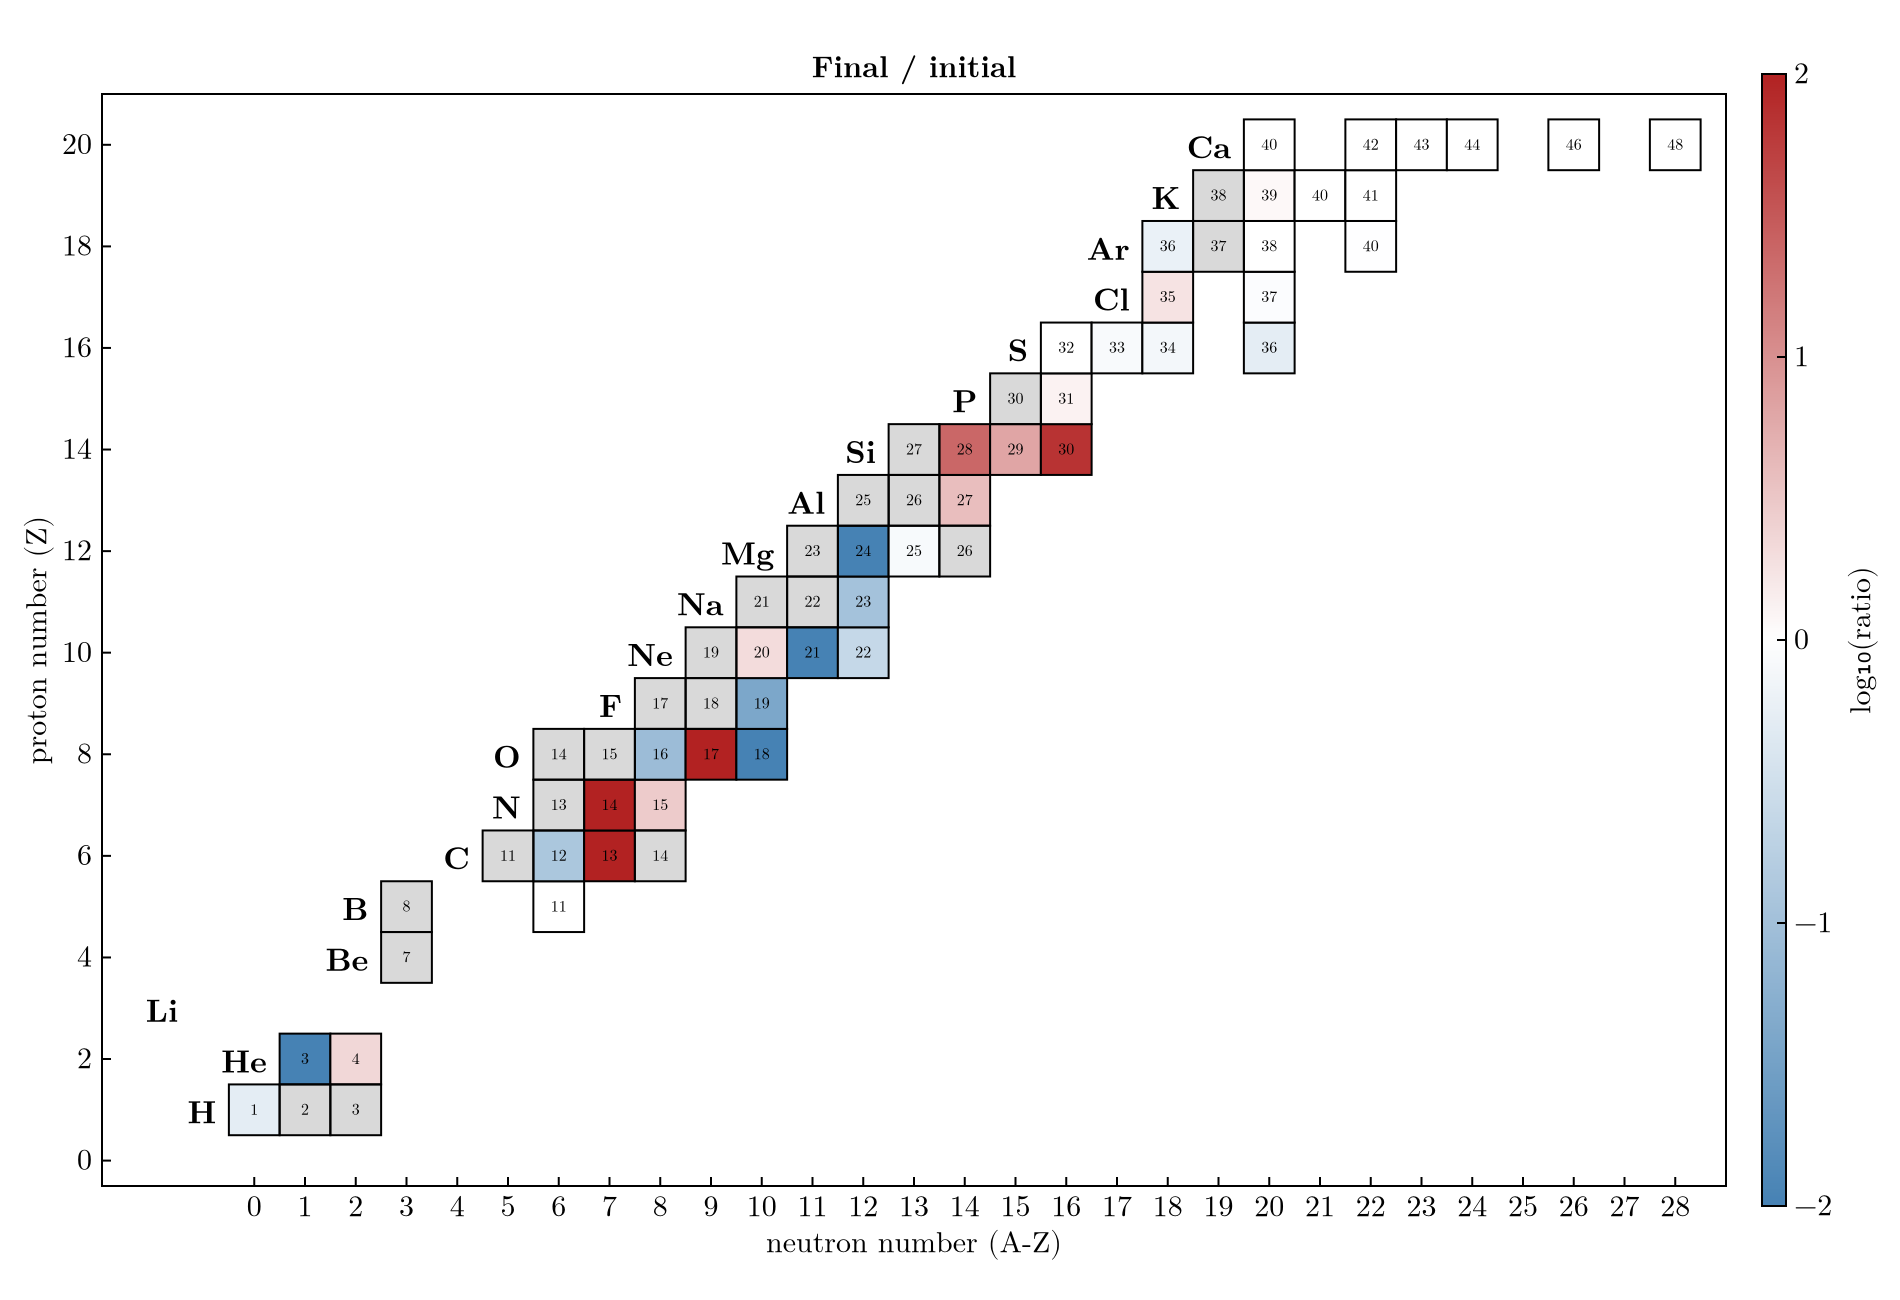

In [2]:
ratio_chart(ab_final, ab_initial; title = "Final / initial")

## `changed_isotopes` — the ranked list

The non-plotting companion: every isotope present in both sets whose ratio
moved by at least `threshold` in log10, ranked by the size of the move —
`ratio_chart`'s picture as a table you can act on.

In [3]:
changed = changed_isotopes(ab_final, ab_initial; threshold = 0.3)
changed[1:8, :]

Row,isotope,Z,A,X1,X2,ratio,log_ratio
,String,Int64,Int64,Float64,Float64,Float64,Float64
1,He-3,2,3,1.01172e-10,2.27e-5,4.45692e-6,-5.35097
2,O-18,8,18,2.198e-10,1.08553e-5,2.02482e-5,-4.69361
3,Mg-24,12,24,6.45922e-7,0.00227616,0.000283777,-3.54702
4,O-17,8,17,0.00419746,1.90663e-6,2201.51,3.34272
5,N-14,7,14,0.364434,0.000529404,688.385,2.83783
6,C-13,6,13,0.0239121,5.11952e-5,467.077,2.66939
7,Ne-21,10,21,1.45592e-7,1.71117e-5,0.00850833,-2.07016
8,Si-30,14,30,0.000936989,1.33639e-5,70.1134,1.8458


Once you've spotted an isotope, `reactions_for_isotope` (from notebook 1)
tells you which reactions in the network could be responsible — the natural
next step into a sensitivity sweep (notebook 4).

In [4]:
net = network(run)
top = changed[1, :]
top_iso = Isotope(Int(top.Z), Int(top.A))
rxns = reactions_for_isotope(net, top_iso)
println(top.isotope, " (log10 ratio = ", round(top.log_ratio, digits=2), ") is touched by ",
        length(rxns), " active reactions:")
describe_rate.(rxns[1:min(5, end)])

He-3 (log10 ratio = 

-5.35) is touched by 16 active reactions:


5-element Vector{String}:
 "2H(p,g)3He         source=VITAL  rate=4.7810e-04  x1"
 "3He(v,v)4He        source=VITAL  rate=1.9820e-15  x1"
 "4He(v,v)7Be        source=VITAL  rate=1.1560e-20  x1"
 "2H(v,v)3He         source=VITAL  rate=5.2550e+00  x1"
 "3He(v,v)4He        source=VITAL  rate=2.7570e-04  x1"

## Abundance vs. time

`abundance_vs_time(run, isotopes)` plots one or more isotopes' mass fraction
against `:time` (default), `:t9`, or `:rho`, reading `x-time.dat`.

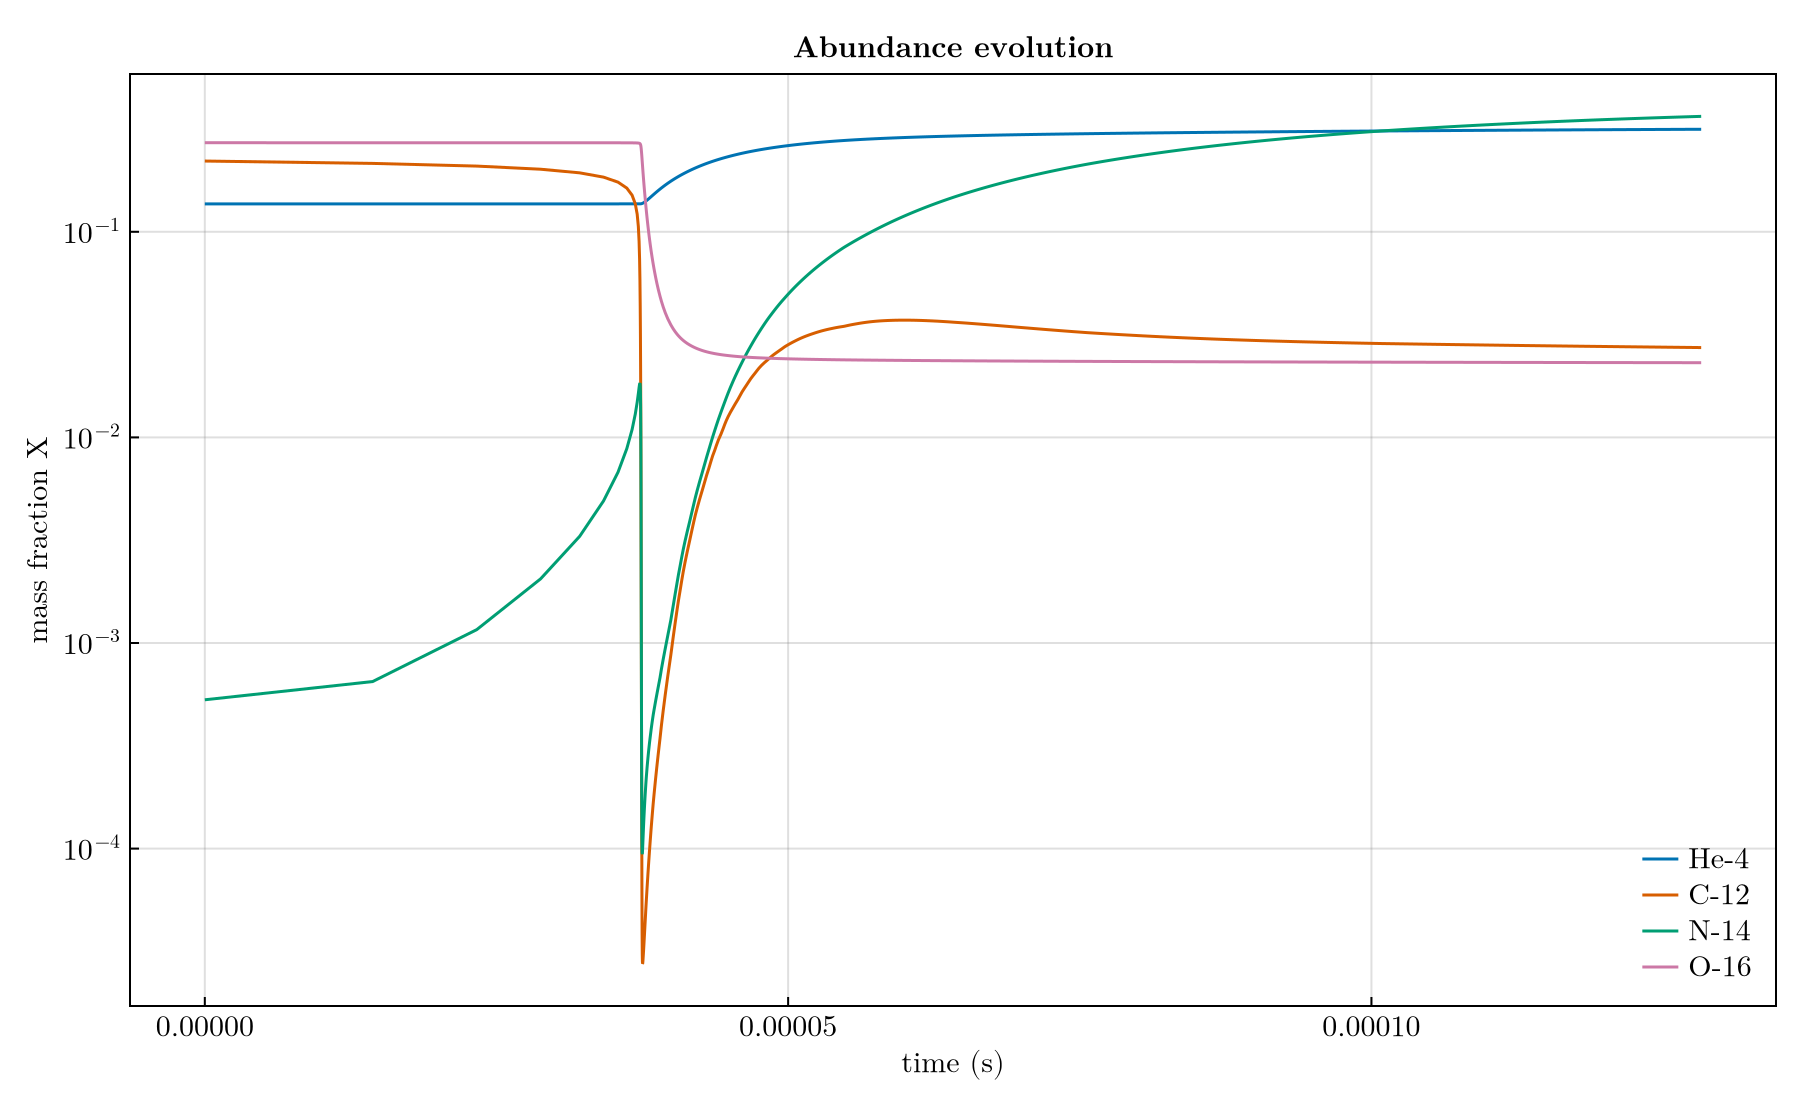

In [5]:
abundance_vs_time(run, ["He-4", "C-12", "N-14", "O-16"])

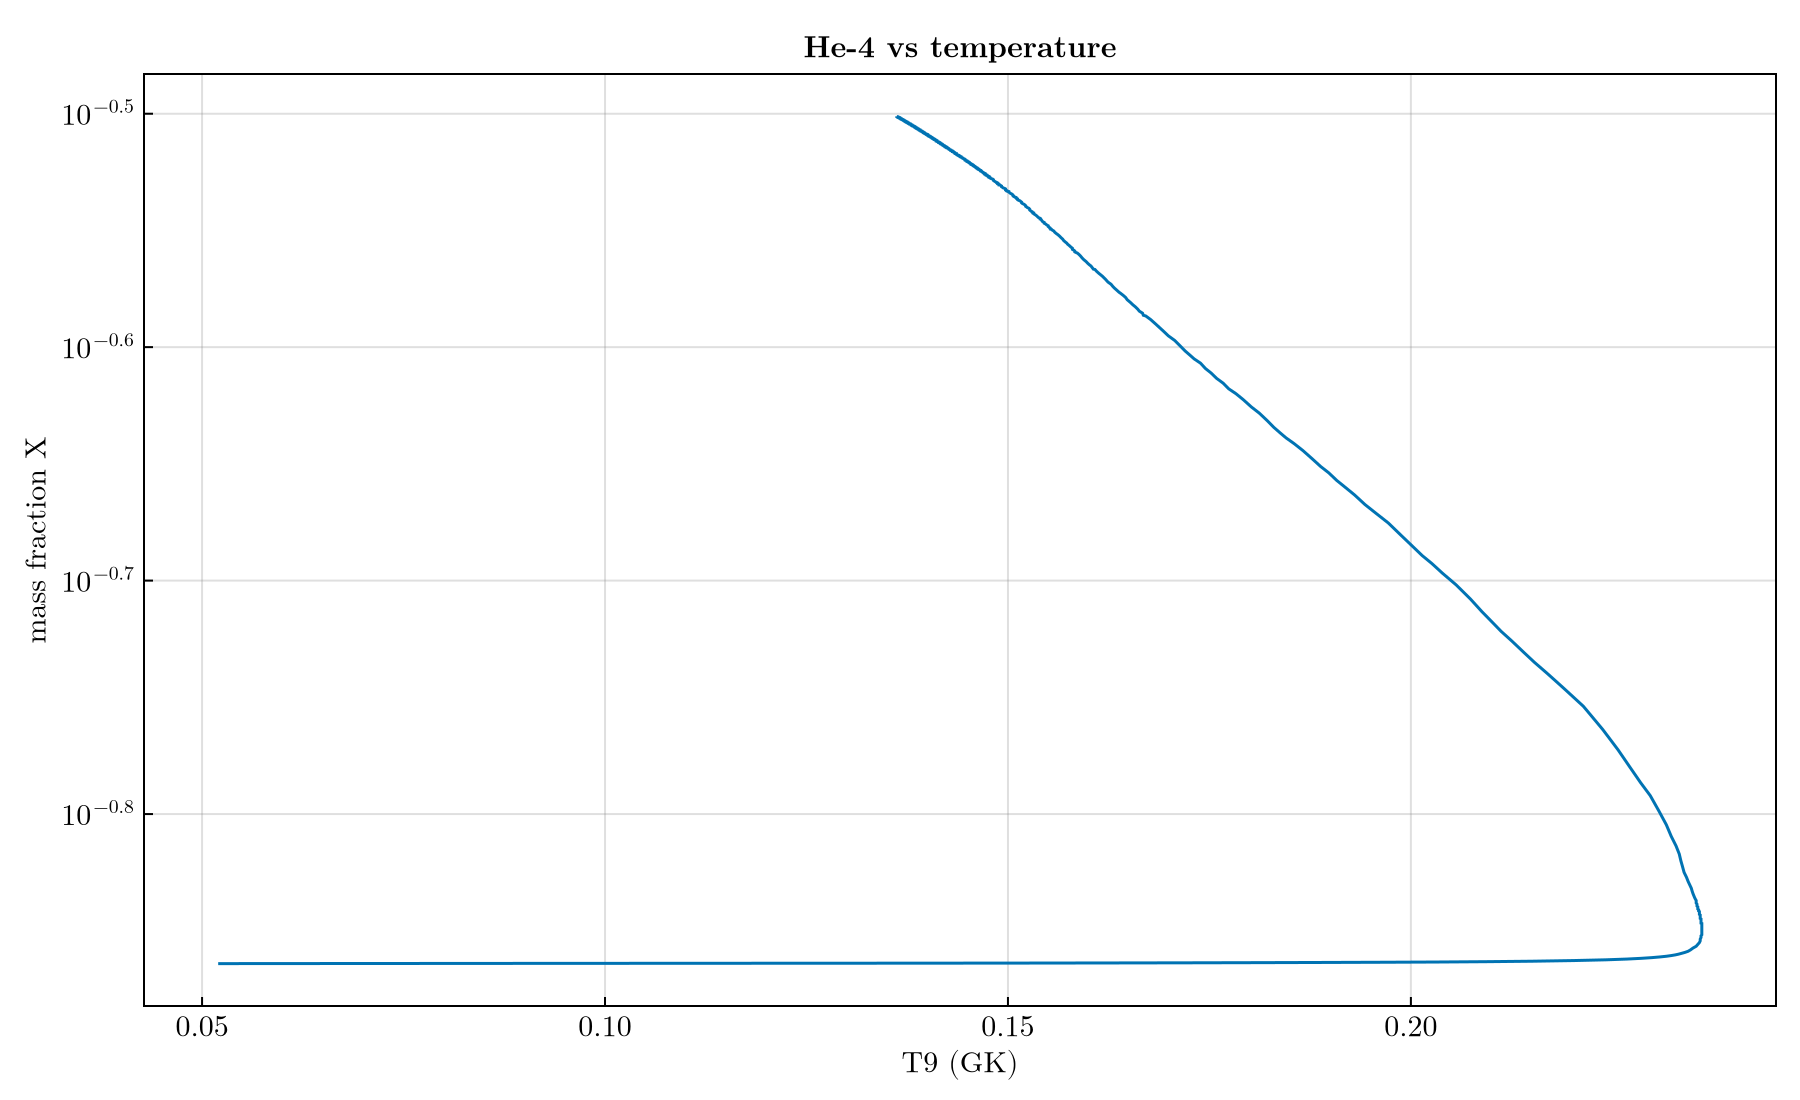

In [6]:
abundance_vs_time(run, "He-4"; x = :t9, title = "He-4 vs temperature")

## Next

[`04_iliadis_sensitivity_sweep.ipynb`](04_iliadis_sensitivity_sweep.ipynb) —
go from "this isotope moved" to "which reaction's rate is responsible."